# An initial training pipeline

In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
import dask.dataframe as dd
import pandas as pd
import numpy as np

from glob import glob
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(ft_dir+'/*.parquet')
df = dd.read_parquet(ft_glob).compute().reset_index().dropna()


c:\Users\semih\miniconda3\envs\dsi_participant\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
cat_file = os.path.join(
    os.getenv("PRICE_CSV_DATA"), 
    'symbols_valid_meta.csv'
)
cat_df = (pd.read_csv(cat_file)
          .rename(columns = {'Symbol': 'ticker'})[['ticker', 'Listing Exchange', 'Market Category']]
          )
df = df.merge(cat_df, on = 'ticker', how = 'left')

In [3]:
df

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1,Listing Exchange,Market Category
0,ACN,2001-07-20,15.05,15.05,14.80,15.01,11.284108,9238500.0,ACN.csv,2001,15.17,N,
1,ACN,2001-07-23,15.00,15.01,14.55,15.00,11.276587,7501000.0,ACN.csv,2001,15.01,N,
2,ACN,2001-07-24,14.95,14.97,14.70,14.86,11.171341,3537300.0,ACN.csv,2001,15.00,N,
3,ACN,2001-07-25,14.70,14.95,14.65,14.95,11.238999,4208100.0,ACN.csv,2001,14.86,N,
4,ACN,2001-07-26,14.95,14.99,14.50,14.50,10.900705,6335300.0,ACN.csv,2001,14.95,N,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
333244,ZIXI,2004-06-28,8.44,8.50,7.66,8.03,8.030000,809200.0,ZIXI.csv,2004,8.66,Q,Q
333245,ZIXI,2004-06-29,8.06,8.06,7.59,7.65,7.650000,467500.0,ZIXI.csv,2004,8.03,Q,Q
333246,ZIXI,2004-06-30,7.64,7.95,7.55,7.89,7.890000,364000.0,ZIXI.csv,2004,7.65,Q,Q
333247,ZIXI,2004-07-01,7.80,7.95,7.56,7.70,7.700000,189600.0,ZIXI.csv,2004,7.89,Q,Q


## Preprocessing

+ Previously, we produced a features data set.
+ Most times, one or more [preprocessing steps](https://scikit-learn.org/stable/modules/preprocessing.html#) steps will be applied to data.
+ The most practical way to apply them is by arranging them in `Pipeline` objects, wchich are sequential transformations applied to data. 
+ It is convenient for us to label these transformations and there is a standard way of doing so.


## Transformations

+ Transformations are classes that implement `fit` and `transform` methods.

### StandardScaler

+ For example, transform a numerical variable by standardizing it.
- Standardization is removing the mean value of the feature and scale it by dividing non-constant features by their standard deviation.

$$
z = \frac{x-\mu}{\sigma}
$$


+  Using [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), one can do the following:

In [4]:
df.columns

Index(['ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'source', 'Year', 'Close_lag_1', 'Listing Exchange', 'Market Category'],
      dtype='object')

In [5]:
df = (df.assign(
        returns = lambda x: x['Close']/x['Close_lag_1'] - 1, 
        positive_return = lambda x: 1.0*(x['returns'] > 0),
        hi_lo = lambda x: x['High'] - x['Low'],
        op_cl = lambda x: x['Close'] - x['Open']
    ).groupby(['ticker'], group_keys=False).apply(
        lambda x: x.assign(target = x['positive_return'].shift(-1))
    )
    .reset_index(drop=True)
    .dropna(subset = ['target'])
    )
df

C:\Users\semih\AppData\Local\Temp\ipykernel_12296\619560177.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = (df.assign(


,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1,Listing Exchange,Market Category,returns,positive_return,hi_lo,op_cl,target
0,ACN,2001-07-20,15.05,15.05,14.80,15.01,11.284108,9238500.0,ACN.csv,2001,15.17,N,,-0.010547,0.0,0.25,-0.04,0.0
1,ACN,2001-07-23,15.00,15.01,14.55,15.00,11.276587,7501000.0,ACN.csv,2001,15.01,N,,-0.000666,0.0,0.46,0.00,0.0
2,ACN,2001-07-24,14.95,14.97,14.70,14.86,11.171341,3537300.0,ACN.csv,2001,15.00,N,,-0.009333,0.0,0.27,-0.09,1.0
3,ACN,2001-07-25,14.70,14.95,14.65,14.95,11.238999,4208100.0,ACN.csv,2001,14.86,N,,0.006057,1.0,0.30,0.25,0.0
4,ACN,2001-07-26,14.95,14.99,14.50,14.50,10.900705,6335300.0,ACN.csv,2001,14.95,N,,-0.030100,0.0,0.49,-0.45,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333243,ZIXI,2004-06-25,8.40,8.66,6.33,8.66,8.660000,1585400.0,ZIXI.csv,2004,8.37,Q,Q,0.034648,1.0,2.33,0.26,0.0
333244,ZIXI,2004-06-28,8.44,8.50,7.66,8.03,8.030000,809200.0,ZIXI.csv,2004,8.66,Q,Q,-0.072748,0.0,0.84,-0.41,0.0
333245,ZIXI,2004-06-29,8.06,8.06,7.59,7.65,7.650000,467500.0,ZIXI.csv,2004,8.03,Q,Q,-0.047322,0.0,0.47,-0.41,1.0
333246,ZIXI,2004-06-30,7.64,7.95,7.55,7.89,7.890000,364000.0,ZIXI.csv,2004,7.65,Q,Q,0.031373,1.0,0.40,0.25,0.0


In [6]:
# Create a StandardScaler object

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()


# Fit the StandardScaler object with the returns data
std_scaler.fit(df.returns.values.reshape(-1,1)) #calls numpy values into pandas with".values"

StandardScaler()

In [7]:
# Transform the returns data using the fitted scaler
returns = df.returns.values.reshape(-1,1)
scaled_returns_np = std_scaler.transform(returns)
scaled_returns = pd.DataFrame(scaled_returns_np, columns=['returns'])
scaled_returns.describe()

,returns
count,3.331600e+05
mean,8.637586e-19
std,1.000002e+00
min,-1.380013e+00
25%,-1.859061e-02
50%,-4.047711e-03
75%,1.026693e-02
max,4.693765e+02


In [8]:
df.returns.describe()

count    333160.000000
mean          0.002866
std           0.708026
min          -0.974218
25%          -0.010297
50%           0.000000
75%           0.010135
max         332.333320
Name: returns, dtype: float64

###  OneHotEncoder

+ Categorical features can be encoded as numerical values using `OneHotEncoder`.

<Axes: xlabel='Listing Exchange'>

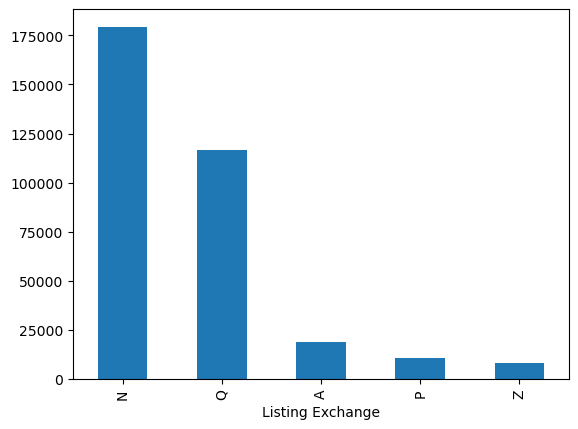

In [9]:
df['Listing Exchange'].value_counts().plot(kind = 'bar')

+ Use [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) to encode a categorical variable as numerical.
+ Important parameters:

    - `categories` allows you to specify the categories to work with.
    - `drop`: we can drop the `'first'` value (dummy encoding) or `'if_binary'`, a convenience setting for binary values.
    - `handle_unknown` allows three options, `'error'`, `'ignore'`, and `'infrequent_if_exist'`, depending on what we want to do with new values.

In [10]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder()
onehot.fit(df[['Listing Exchange']])

OneHotEncoder()

In [11]:
listing_enc = onehot.transform(df[['Listing Exchange']])
listing_enc.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.]])

# Pipelines

+ It is impractical and costly to manipulate data "by hand". 
+ To manage data preprocessing steps within the cross-validation process use `Pipeline` objects.
+ A [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object allows us to sequentially apply transformation steps and, if required, a predictor.
+ `Pipeline` objects compose transforms, i.e., classes that implement `transform` and `fit` methods.
+ The purpose of `Pipeline` objects is to ensemble transforms and predictors to be used in cross-validation.
+ A `Pipeline` is defined by a list of tuples.
+ Each tuple is composed of `("name", <ColumnTransformer>)`, the name of the step and the `<ColumnTransformer>` function of our chosing.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, cohen_kappa_score, f1_score


In [13]:
pipe1 = Pipeline(
    [
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ('knn', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))

    ]
)
pipe1

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('knn',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

In [14]:
X0 = df[['Listing Exchange', 'Market Category']]
Y0 = df['target']
X0_train, X0_test, Y0_train, Y0_test = train_test_split(X0, Y0, test_size=0.2, random_state=42)

pipe1.fit(X0_train, Y0_train)

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('knn',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

In [15]:
Y_pred_train = pipe1.predict(X0_train)
Y_pred_test = pipe1.predict(X0_test)

In [16]:
Y_poba_train = pipe1.predict_proba(X0_train)
Y_proba_test = pipe1.predict_proba(X0_test)

In [17]:
Y_pred_train
Y_poba_train

array([[0.53355262, 0.46644738],
       [0.62605262, 0.37394738],
       [0.53355262, 0.46644738],
       ...,
       [0.53355262, 0.46644738],
       [0.53355262, 0.46644738],
       [0.53355262, 0.46644738]])

In [18]:
res = {
    'accuracy_score_train': accuracy_score(Y0_train, Y_pred_train),
    'accuracy_score_test': accuracy_score(Y0_test, Y_pred_test),
    'cohen_kappa_train': cohen_kappa_score(Y0_train, Y_pred_train),
    'cohen_kappa_test': cohen_kappa_score(Y0_test, Y_pred_test),
    'log_loss_train': log_loss(Y0_train, Y_poba_train),
    'log_loss_test': log_loss(Y0_test, Y_proba_test),
    'f1_score_train': f1_score(Y0_train, Y_pred_train),
    'f1_score_test': f1_score(Y0_test, Y_pred_test)
}
res

{'accuracy_score_train': 0.5531876575819427,
 'accuracy_score_test': 0.5521821347100492,
 'cohen_kappa_train': np.float64(0.0),
 'cohen_kappa_test': np.float64(0.0),
 'log_loss_train': 0.6848218101750948,
 'log_loss_test': 0.6847993632734996,
 'f1_score_train': 0.0,
 'f1_score_test': 0.0}

+ The model does not show great performance, but the pipeline shows results. 
+ Below, we expand the pipeline to include more variables, and further we will work with more robust model selection pipelines.

## ColumnTransformer

+ Use [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to apply transformers to specific columns of a DataFrame.
+ In this case, we will scale numeric variables and apply one-hot encoding to categorical columns.

In [19]:
from sklearn.compose import ColumnTransformer

In [20]:
transformer = ColumnTransformer(
    transformers=[
        ('numeric_transfomer', StandardScaler(), ['returns', 'Volume', 'op_cl', 'hi_lo'] ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['Listing Exchange', 'Market Category']), 
    ], remainder='drop'
)

pipe = Pipeline(
    [
        ('preproc', transformer), 
        ('decisiontree', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))
    ]
)

pipe

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('numeric_transfomer',
                                                  StandardScaler(),
                                                  ['returns', 'Volume', 'op_cl',
                                                   'hi_lo']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['Listing Exchange',
                                                   'Market Category'])])),
                ('decisiontree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

# Model Selection

The model selection process is an iterative process in which :

+ Select schema and load data.
+ Define a pipeline and its (hyper) parameters.

    - Use ColumnTransformers to transform numeric and cateogrical variables.
    - Hyperparameters can be defined independently of code. 

+ Implement a splitting strategy. 

    - Use [cross_validate]() to select several metrics and operational details.

+ Measure performance.

    - [Select metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

+ Repeat

## Training, Validation, Testing Split

+ The first spliting strategy is to use a training, validation, and test set.
+ Training set will be used to fit the model.
+ Validation set is used to evaluate hyperparameter choice.
+ Testing set is used to evaluate performance on data the model has not yet seen.
+ In this case we want to compare two models: 

    - Decision Tree with 3 minumum samples per leaf.
    - Decision Tree with 10 minimum samples per leaf.

![](./images/03b_train_validate_test.png)

## Setting parameters in pipeline steps

+ One can obtain the parameters of a pipeline with `pipe.get_params()`.
+ We can set any parameter of a pipeline with `pipe.set_parames(**kwargs)`. 
+ The input `**kwargs` is a dictionary of the params to be modified. Params of the steps are labeled with the name of the step followed by `__` and the name of the parameter.

+ There are a few steps that we will repeat: 

    - Fit the candidate model on training data.
    - Predict on training and test data.
    - Compute training and test performance metrics.
    - Return.

+ We encapsulate this procedure in a function. 

In [21]:
def evaluate_model(clf, X_train, Y_train, X_test, Y_test):
    clf.fit(X_train, Y_train)
    Y_pred_train = clf.predict(X_train)
    Y_pred_test = clf.predict(X_test)
    Y_proba_train = clf.predict_proba(X_train)
    Y_proba_test = clf.predict_proba(X_test)
    performance_metrics = {
        'log_loss_train': log_loss(Y_train, Y_proba_train),
        'log_loss_test': log_loss(Y_test, Y_proba_test),
        'cohen_kappa_train': cohen_kappa_score(Y_train, Y_pred_train),
        'cohen_kappa_test': cohen_kappa_score(Y_test, Y_pred_test),
        'f1_score_train': f1_score(Y_train, Y_pred_train),
        'f1_score_test': f1_score(Y_test, Y_pred_test),
        'accuracy_score_train': accuracy_score(Y_train, Y_pred_train),
        'accuracy_score_test': accuracy_score(Y_test, Y_pred_test),
    }
    return performance_metrics

In [22]:
# Schema
X = df[['returns', 'op_cl', 'hi_lo', 'Volume', 'Listing Exchange', 'Market Category']]
Y = df['target']

# Split the data
X_rest, X_test, Y_rest, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_validate, Y_train,  Y_validate = train_test_split(X_rest, Y_rest, test_size=0.2, random_state=42)


In [23]:
# Evaluate hyperparameter configuration 2
pipe_d3 = pipe.set_params(**{'decisiontree__max_depth': 3})
res_d3 = evaluate_model(pipe_d3, X_train, Y_train, X_validate, Y_validate)
res_d3

{'log_loss_train': 0.6741029057861398,
 'log_loss_test': 0.6741034334920671,
 'cohen_kappa_train': np.float64(0.0),
 'cohen_kappa_test': np.float64(0.0),
 'f1_score_train': 0.0,
 'f1_score_test': 0.0,
 'accuracy_score_train': 0.553540441417865,
 'accuracy_score_test': 0.5517765354744306}

In [24]:
pipe.get_params()

{'memory': None,
 'steps': [('preproc',
   ColumnTransformer(transformers=[('numeric_transfomer', StandardScaler(),
                                    ['returns', 'Volume', 'op_cl', 'hi_lo']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['Listing Exchange', 'Market Category'])])),
  ('decisiontree', DecisionTreeClassifier(criterion='entropy', max_depth=3))],
 'transform_input': None,
 'verbose': False,
 'preproc': ColumnTransformer(transformers=[('numeric_transfomer', StandardScaler(),
                                  ['returns', 'Volume', 'op_cl', 'hi_lo']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                  ['Listing Exchange', 'Market Category'])]),
 'decisiontree': DecisionTreeClassifier(criterion='entropy', max_depth=3),
 'preproc__force_int_

In [25]:
# Evaluate hyperparameter configuration 2
pipe_d15 = pipe.set_params(**{'decisiontree__max_depth':15}) # key equals value 
res_d15 = evaluate_model(pipe_d15, X_train, Y_train, X_validate, Y_validate)
res_d15

{'log_loss_train': 0.6329652081674559,
 'log_loss_test': 1.347957690260271,
 'cohen_kappa_train': np.float64(0.15267092358539247),
 'cohen_kappa_test': np.float64(0.06419153866975469),
 'f1_score_train': 0.47275438032957773,
 'f1_score_test': 0.41932758911978374,
 'accuracy_score_train': 0.5919980114622319,
 'accuracy_score_test': 0.5486624395002438}

## Cross-Validation

+ Cross-validation is a resampling method.
+ It is an iterative method applied to training data.
+ Training data is divided into folds.
+ Each fold is used once as a validation set and the rest of the folds are used for training.
+ Test data is used for final evaluation.

From [Scikit's Documentation ](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance), the diagram below shows the data divisions and folds during the cross-validation process.

![](./images/03b_grid_search_cross_validation.png)

There are two functions that can be used for [calculating cross-validation performance scores](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance): `cross_val_score()` and `cross_validate()`. The first function, [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score), is a convenience function to get quick perfromance calculations. We will discuss `cross_validate()` as it offers advantages over `cross_val_score()`.

## Obtaining metrics

+ Use [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) to measure one or more performance metrics and operational details.
+ There are two advantages of using this function. From [Scikit's documentation](https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation):

>- It allows specifying multiple metrics for evaluation.
>- It returns a dict containing fit-times, score-times (and optionally training scores, fitted estimators, train-test split indices) in addition to the test score.


In [26]:
from sklearn.model_selection import cross_validate
scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc', 'neg_log_loss', 'neg_brier_score']
d3_dict = cross_validate(pipe_d3, X, Y, cv=5, scoring = scoring, return_train_score = True) # this is a dictionary

In DataFrame form:

In [27]:
pd.DataFrame(d3_dict) # but we like data frames

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,1.442775,0.081496,0.546644,0.584633,0.451382,0.489978,0.491633,0.543070,0.417223,0.446341,0.556803,0.633007,-1.361135,-0.636171,-0.253349,-0.226663
1,1.410344,0.084207,0.545188,0.588043,0.342268,0.468656,0.484039,0.553394,0.264731,0.406423,0.553047,0.635650,-2.249930,-0.635105,-0.266878,-0.226387
2,1.431457,0.082314,0.530676,0.585833,0.468760,0.455097,0.474433,0.552463,0.463220,0.386908,0.533598,0.632302,-2.311594,-0.636721,-0.273846,-0.226760
3,1.414691,0.078726,0.528215,0.588921,0.363386,0.465442,0.457895,0.555796,0.301215,0.400358,0.535833,0.636921,-2.345881,-0.634078,-0.273294,-0.225809
4,1.441386,0.080894,0.551312,0.583548,0.356098,0.392967,0.496666,0.563923,0.277546,0.301550,0.566788,0.627204,-1.630212,-0.639852,-0.258842,-0.228011


In [28]:
d15_dict = cross_validate(pipe_d15, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(d15_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,1.442935,0.081478,0.546944,0.584637,0.451267,0.489853,0.492013,0.543100,0.416753,0.446115,0.557216,0.632996,-1.355458,-0.636184,-0.253103,-0.226669
1,1.450415,0.082612,0.545264,0.588032,0.342448,0.468618,0.484198,0.553383,0.264898,0.406372,0.553264,0.635619,-2.237006,-0.635128,-0.266714,-0.226395
2,1.463623,0.086729,0.531381,0.585785,0.467577,0.454696,0.475054,0.552464,0.460332,0.386329,0.534247,0.632225,-2.243350,-0.636682,-0.272663,-0.226755
3,1.434566,0.081339,0.528125,0.588895,0.362929,0.465458,0.457686,0.555743,0.300678,0.400408,0.535675,0.636889,-2.352698,-0.634067,-0.273403,-0.225806
4,1.404528,0.079302,0.551837,0.583458,0.356617,0.393154,0.497715,0.563639,0.277849,0.301852,0.567803,0.627117,-1.617764,-0.639830,-0.258478,-0.228009


# About Performance

+ Notice that in order to acquire information about our model and continue development, we are spending resources: time, electricity, equipment use, etc. As well, we are generating data and binary objects that implement our models (fitted `Pipeline` objects, for example).
+ For certain applications, operating performance (latency or `'score_time'`) may be as important or more important than predictive performance metrics. 
+ Every experiment throws important information and we can log them, as well as run them systematically.

In [29]:
pd.DataFrame(d15_dict).mean()

fit_time                 1.439213
score_time               0.082292
test_accuracy            0.540710
train_accuracy           0.586161
test_f1                  0.396168
train_f1                 0.454356
test_precision           0.481333
train_precision          0.553666
test_recall              0.344102
train_recall             0.388215
test_roc_auc             0.549641
train_roc_auc            0.632969
test_neg_log_loss       -1.961255
train_neg_log_loss      -0.636378
test_neg_brier_score    -0.264872
train_neg_brier_score   -0.226727
dtype: float64